# 2.10 Ruido sintético
***Generación de ruido sintético y datos sintéticos para las geociencias***

## 1. Introducción

El ruido en los datos geocientíficos proviene del entorno, del instrumento y de la actividad humana. Si podemos simular el ruido, podemos construir conjuntos de datos controlados con una verdad de referencia conocida. Eso permite probar filtros, evaluar detectores contra puntos de comparación y aumentar los conjuntos de entrenamiento para el aprendizaje automático.

Esta lección cubre el ruido sintético en dos contextos:
1. **Series de tiempo 1D**: registros sísmicos, presión atmosférica, temperatura superficial del mar.
2. **Campos geoespaciales 2D**: topografía, humedad del suelo, mapas de temperatura.

Terminamos con un ejemplo sismológico realista y una discusión sobre cuándo los datos sintéticos son admisibles en la investigación.

### Tipos de ruido
- **Ruido blanco**: densidad espectral de potencia constante en todas las frecuencias. Típico del ruido instrumental.
- **Ruido rosa**: densidad espectral de potencia proporcional a $1/f$. Común en sistemas naturales como los registros climáticos.
- **Ruido gaussiano**: ruido cuya distribución de amplitudes es normal. El ruido blanco suele extraerse de una gaussiana.
- **Ruido espacialmente correlacionado**: ruido que varía suavemente en el espacio, como los artefactos atmosféricos o de sensor en los mapas.

A lo largo de este cuaderno usamos el generador aleatorio moderno de numpy, con semilla fija por reproducibilidad. La semilla importa: un conjunto de datos sintético que no puede regenerarse no es reproducible.

🖥️ [**Diapositivas — Sesión 09 (lun 19 oct)**](https://geo-smart.github.io/mlgeo-book/slides/2026/lec09_synthetic_truth.html)

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

## 2. Modelos de ruido en 1D y 2D

### 2.1 Ruido blanco y ruido rosa (1D)

El ruido blanco es una secuencia de extracciones gaussianas independientes. El ruido rosa se construye en el dominio de la frecuencia: imponemos un espectro de amplitud proporcional a $1/\sqrt{f}$ (de modo que la *potencia* vaya como $1/f$), sorteamos fases aleatorias y transformamos de regreso al dominio del tiempo. Usamos `np.fft.irfft`, que toma el espectro solo en las frecuencias no negativas y devuelve una señal real por construcción.

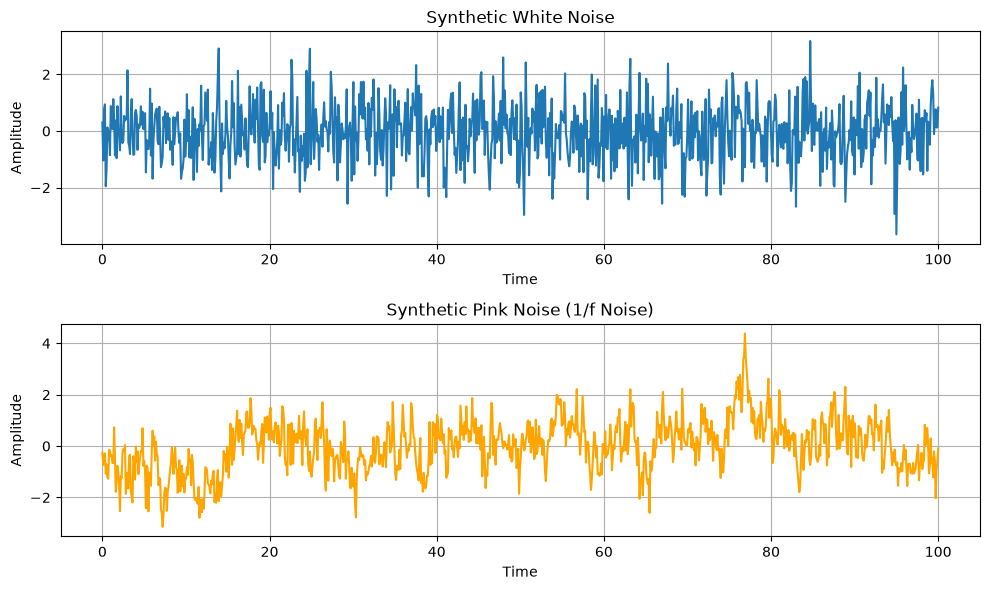

In [2]:
n = 1000  # number of time points
time = np.linspace(0, 100, n)

# White noise: independent Gaussian draws, zero mean
white_noise = rng.standard_normal(n)


def generate_pink_noise(size, rng):
    """Pink (1/f) noise: power spectral density proportional to 1/f.

    Build the one-sided spectrum with amplitude 1/sqrt(f) and random
    phases, then invert with irfft to get a real time series.
    """
    freqs = np.fft.rfftfreq(size)
    amplitude = np.zeros_like(freqs)
    amplitude[1:] = 1.0 / np.sqrt(freqs[1:])  # skip f=0 to avoid division by zero
    phases = rng.uniform(0, 2 * np.pi, len(freqs))
    spectrum = amplitude * np.exp(1j * phases)
    pink = np.fft.irfft(spectrum, n=size)
    return pink / np.std(pink)


pink_noise = generate_pink_noise(n, rng)

plt.figure(figsize=(10, 6))
plt.subplot(2, 1, 1)
plt.plot(time, white_noise, label='White Noise')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.title('Synthetic White Noise')
plt.grid()

plt.subplot(2, 1, 2)
plt.plot(time, pink_noise, label='Pink Noise', color='orange')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.title('Synthetic Pink Noise (1/f Noise)')
plt.grid()

plt.tight_layout()
plt.show()

El ruido blanco fluctúa rápidamente, sin memoria de una muestra a la siguiente. El ruido rosa deambula: las frecuencias bajas concentran la mayor parte de la potencia, así que la serie deriva en escalas de tiempo largas.

**Aplicaciones.** El ruido blanco simula el autorruido instrumental en los registros sísmicos o atmosféricos. El ruido rosa imita la variabilidad natural, dominada por las frecuencias bajas en muchos procesos geofísicos.

### 2.2 Ruido espacialmente correlacionado (2D)

El ruido geoespacial rara vez es independiente de un píxel al siguiente. La interferencia atmosférica y la deriva de los sensores varían suavemente en el espacio. Una manera simple de simularlo: generar un campo 2D de ruido blanco y luego suavizarlo con un filtro gaussiano. El ancho del filtro fija la longitud de correlación.

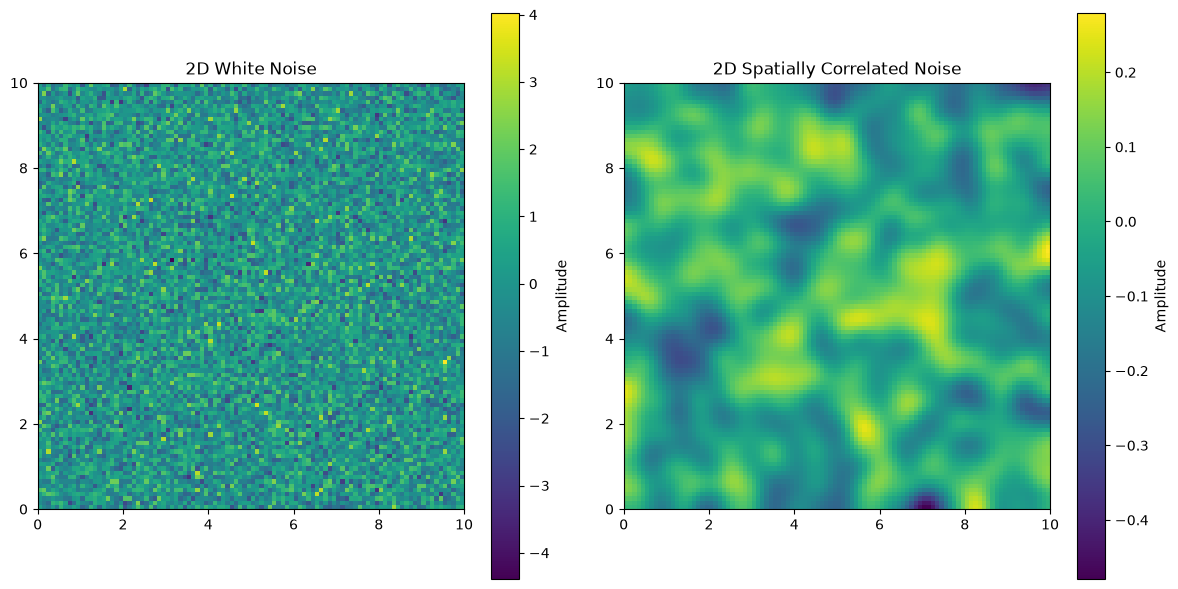

In [3]:
from scipy.ndimage import gaussian_filter

ngrid = 100  # size of the grid
x = np.linspace(0, 10, ngrid)
y = np.linspace(0, 10, ngrid)
X2d, Y2d = np.meshgrid(x, y)

# 2D white noise
white_noise_2d = rng.standard_normal((ngrid, ngrid))

# Spatially correlated noise: smooth the white noise
spatially_correlated_noise = gaussian_filter(white_noise_2d, sigma=3)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(white_noise_2d, extent=[0, 10, 0, 10], cmap='viridis')
plt.colorbar(label='Amplitude')
plt.title('2D White Noise')

plt.subplot(1, 2, 2)
plt.imshow(spatially_correlated_noise, extent=[0, 10, 0, 10], cmap='viridis')
plt.colorbar(label='Amplitude')
plt.title('2D Spatially Correlated Noise')

plt.tight_layout()
plt.show()

**Aplicaciones.** El ruido espacialmente correlacionado simula la distorsión atmosférica en las imágenes satelitales, los artefactos de interpolación en los productos en malla y los errores suaves de sensor en los mapas geofísicos.

## 3. Eventos transitorios sintéticos

Ahora construimos una serie de tiempo que contiene un evento transitorio más ruido. Este es el ingrediente básico de un problema de clasificación binaria: ¿contiene una ventana **señal** o solo **ruido**?

### 3.1 La señal del evento: la ondícula de Ricker

La ondícula (*wavelet*) de Ricker, también llamada ondícula de sombrero mexicano, es un modelo estándar de una fuente sísmica impulsiva. Es la segunda derivada negativa de una gaussiana. `scipy.signal.ricker` fue eliminada de las versiones recientes de scipy, así que la definimos nosotros mismos.

In [4]:
import scipy.signal as sig


def ricker(t, a):
    """Ricker (Mexican-hat) wavelet.

    Parameters
    ----------
    t : array
        Time axis in seconds, centered on zero.
    a : float
        Width parameter in seconds. The amplitude spectrum peaks near
        sqrt(2) / (2 * pi * a) Hz.

    Returns
    -------
    array
        The wavelet 2/(sqrt(3a) * pi**0.25) * (1 - (t/a)**2) * exp(-t**2/(2a**2)).
    """
    prefactor = 2.0 / (np.sqrt(3.0 * a) * np.pi**0.25)
    return prefactor * (1.0 - (t / a) ** 2) * np.exp(-(t**2) / (2.0 * a**2))

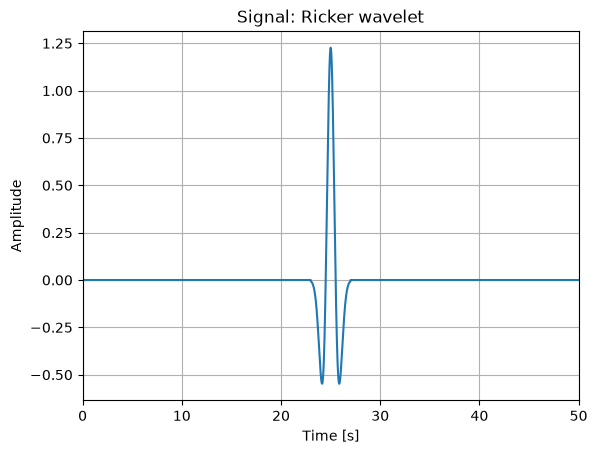

In [5]:
fs = 100.0   # sampling rate in Hz
twin = 50.0  # window length in seconds
t = np.linspace(0, twin, int(twin * fs))

a = 0.5  # width parameter in seconds
t_wavelet = np.arange(-2, 2, 1 / fs)  # 4 seconds of support
sa = ricker(t_wavelet, a)

# place the wavelet in the middle of the time series
pad = len(t) // 2 - len(sa) // 2
s = np.concatenate((np.zeros(pad), sa, np.zeros(len(t) - pad - len(sa))))

plt.figure()
plt.plot(t, s)
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.grid()
plt.xlim([0, 50])
plt.title('Signal: Ricker wavelet')
plt.show()

La ondícula de Ricker es suave y de banda limitada. Grafiquemos el valor absoluto de su espectro de amplitud de Fourier.

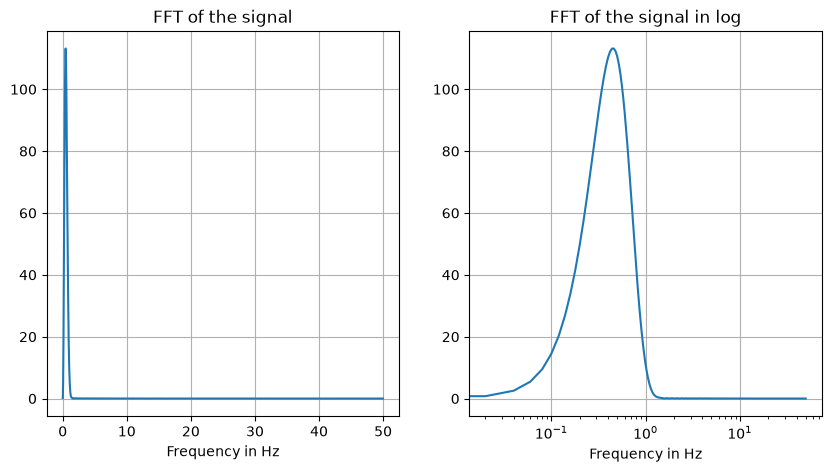

In [6]:
from scipy.fft import fft, fftfreq, next_fast_len

# pad to a fast FFT length
Nfft = next_fast_len(len(s))  # this will be an even number

freqVec = fftfreq(Nfft, d=1 / fs)[: Nfft // 2]
Zhat = fft(s, n=Nfft)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].plot(freqVec, np.abs(Zhat[: Nfft // 2]))
ax[0].grid()
ax[0].set_title('FFT of the signal')
ax[0].set_xlabel('Frequency in Hz')
ax[1].plot(freqVec, np.abs(Zhat[: Nfft // 2]))
ax[1].set_xscale('log')
ax[1].set_xlabel('Frequency in Hz')
ax[1].set_title('FFT of the signal in log')
ax[1].grid()

¿Cómo se ve la distribución de los datos del evento?

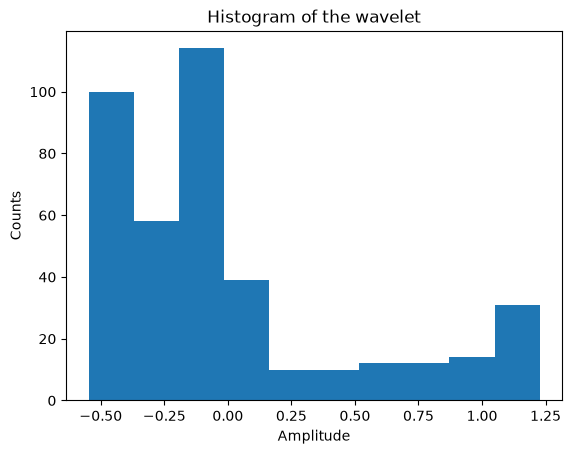

In [7]:
plt.hist(sa, bins=10)
plt.xlabel('Amplitude')
plt.ylabel('Counts')
plt.title('Histogram of the wavelet')
plt.show()

### 3.2 Ruido gaussiano y relación señal-ruido

Creamos una señal pura. Ahora creamos una serie de tiempo de *ruido* para sumársela.

Una precaución: `np.random.uniform(0, 1)` sortea valores entre 0 y 1, cuya media es 0.5. Sumar eso a una señal introduce un desplazamiento de nivel medio (DC) — un pico espurio en la frecuencia cero del espectro. Usamos en cambio `rng.standard_normal`, que tiene media cero por construcción.

Una sola definición, usada en todas partes. Definimos la **relación señal-ruido (SNR)** como la amplitud absoluta pico de la señal dividida por la desviación estándar del ruido. Esta es la definición incorporada en `mlgeo_synth` y la que usan los experimentos con detectores del [capítulo 4.3](../Chapter4-DeepLearning/mlgeo_4.3_CNN.ipynb). Mantener una sola definición importa: una afirmación como «el detector falla por debajo de SNR 1» no significa nada si dos capítulos miden la SNR de maneras distintas. En el código, normalizamos la señal a amplitud pico unitaria y el ruido a desviación estándar unitaria, de modo que `s + noise / SNR` tenga exactamente la SNR declarada.

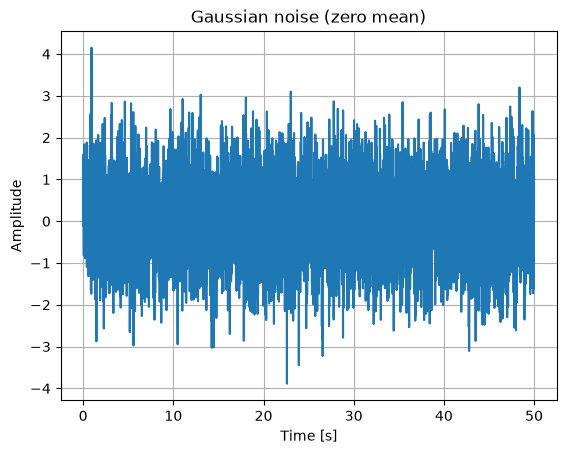

In [8]:
noise = rng.standard_normal(len(s))
plt.figure()
plt.plot(t, noise)
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.grid()
plt.title('Gaussian noise (zero mean)')
plt.show()

Compare el espectro de amplitud de Fourier del ruido contra el espectro de la señal.

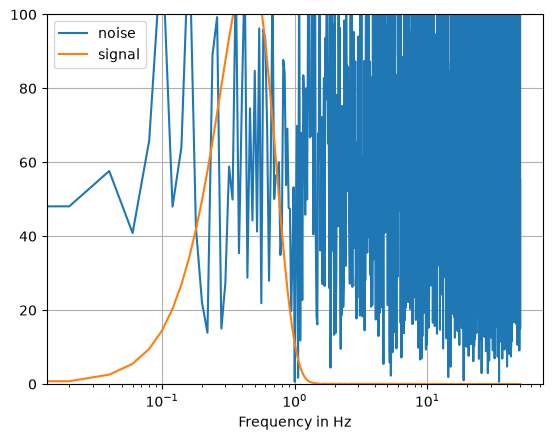

In [9]:
nhat = fft(noise, n=Nfft)
plt.plot(freqVec, np.abs(nhat[: Nfft // 2]))
plt.plot(freqVec, np.abs(Zhat[: Nfft // 2]))
plt.xscale('log')
plt.legend(['noise', 'signal'])
plt.xlabel('Frequency in Hz')
plt.ylim([0, 100])
plt.grid()

Se ven muy distintos en el dominio espectral. El ruido reparte su energía en todas las frecuencias; la señal concentra la suya en una banda angosta.

Ahora sumamos el ruido a la señal, escalado por una relación señal-ruido (SNR). Definimos aquí la SNR como el cociente entre la amplitud absoluta máxima de la señal y la del ruido. Primero normalizamos ambas y luego dividimos el ruido por la SNR.

Text(0.5, 0, 'Time in s')

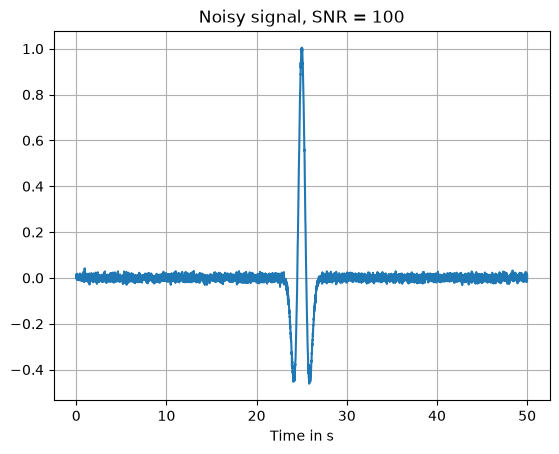

In [10]:
SNR = 100  # signal-to-noise ratio

s /= np.max(np.abs(s))  # unit peak amplitude
noise /= noise.std()    # unit standard deviation, so s + noise / SNR has the stated SNR

noisy_signal = s + noise / SNR
plt.plot(t, noisy_signal)
plt.grid()
plt.title(f'Noisy signal, SNR = {SNR}')
plt.xlabel('Time in s')

### 3.3 Ruido con un color elegido: aleatorizar la fase

El ruido puede tener distinto contenido de frecuencia, o *color*. Una receta general construye una serie de tiempo de ruido a partir de un espectro de amplitud de Fourier elegido:
1. Elija la amplitud en cada frecuencia no negativa (plana para el ruido blanco, un decaimiento $1/f$ para el ruido coloreado, o el espectro de datos reales).
2. Sortee una fase aleatoria en cada frecuencia, uniforme entre $0$ y $2\pi$.
3. Invierta con `np.fft.irfft`.

Una serie de tiempo de valores reales requiere un espectro con simetría hermitiana: el valor en $-f$ debe ser el conjugado complejo del valor en $+f$. Programar esa simetría a mano es propenso a errores. `irfft` toma solo las frecuencias no negativas y aplica la simetría por construcción, así que la usamos. Los intervalos (*bins*) de la frecuencia cero y de Nyquist deben ser reales, así que fijamos sus fases en cero.

Text(0.5, 1.0, 'Noise with random phase and white spectrum')

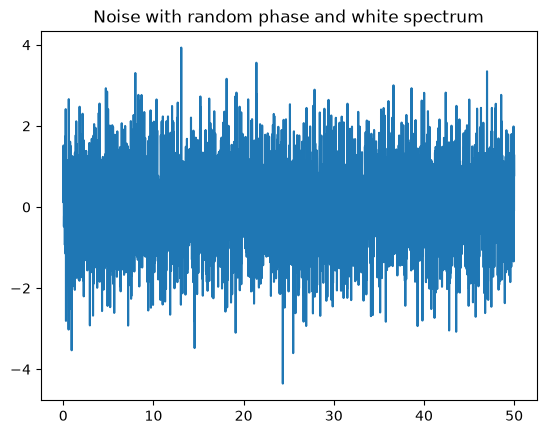

In [11]:
n_rfreq = Nfft // 2 + 1  # number of non-negative frequency bins
phases = rng.uniform(0, 2 * np.pi, n_rfreq)
phases[0] = 0.0    # DC bin must be real
phases[-1] = 0.0   # Nyquist bin must be real (Nfft is even)

amplitude = np.ones(n_rfreq)  # flat spectrum: white noise
amplitude[0] = 0.0            # no DC component

spectrum = amplitude * np.exp(1j * phases)
noise = np.fft.irfft(spectrum, n=Nfft)[: len(s)]

noise /= noise.std()  # unit standard deviation
plt.plot(t, noise)
plt.title('Noise with random phase and white spectrum')

Sume el ruido nuevo a la señal (la ondícula de Ricker), esta vez con una SNR mucho menor, y grafique en los dominios del tiempo y de la frecuencia.

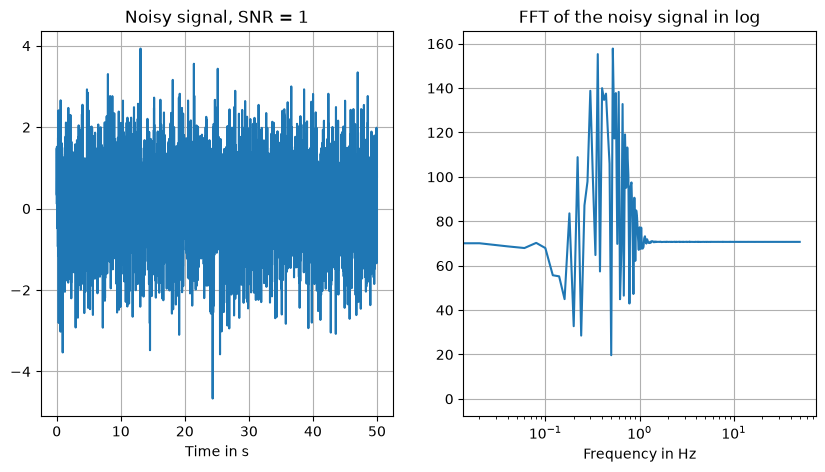

In [12]:
SNR = 1
news = s + noise / SNR

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].plot(t, news)
ax[0].set_title(f'Noisy signal, SNR = {SNR}')
ax[0].set_xlabel('Time in s')
ax[0].grid()
ax[1].plot(freqVec, np.abs(fft(news, n=Nfft)[: Nfft // 2]))
ax[1].set_xscale('log')
ax[1].grid()
ax[1].set_xlabel('Frequency in Hz')
ax[1].set_title('FFT of the noisy signal in log');

Compare las distribuciones de los datos de la señal pura, del ruido y de su suma.

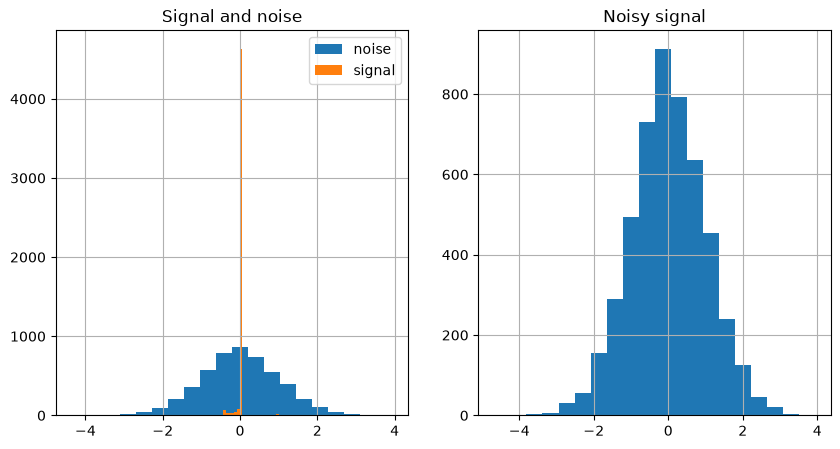

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].hist(noise, bins=20, label='noise')
ax[0].hist(s, bins=20, label='signal')
ax[0].legend()
ax[0].grid()
ax[0].set_title('Signal and noise')
ax[1].hist(news, bins=20)
ax[1].grid()
ax[1].set_title('Noisy signal');

### 3.4 Momentos estadísticos

Calcule los momentos estadísticos de la señal limpia y del ruido. ¿Qué momentos discriminan entre **señal** y **ruido**, y qué tan sensibles son al nivel de ruido?

In [14]:
from scipy.stats import moment

print('The first moment of the signal is:', moment(s, 1))
print('The second moment of the signal is:', moment(s, 2))
print('The third moment of the signal is:', moment(s, 3))
print('The fourth moment of the signal is:', moment(s, 4))

print('The first moment of the noise is:', moment(noise, 1))
print('The second moment of the noise is:', moment(noise, 2))
print('The third moment of the noise is:', moment(noise, 3))
print('The fourth moment of the noise is:', moment(noise, 4))

The first moment of the signal is: 0.0
The second moment of the signal is: 0.013293333067181288
The third moment of the signal is: 0.006430940666682904
The fourth moment of the signal is: 0.007489819567378666
The first moment of the noise is: 0.0
The second moment of the noise is: 1.0
The third moment of the noise is: 0.005114776505715557
The fourth moment of the noise is: 3.134334832790316


El primer momento central es cero por definición. El segundo momento (la varianza) depende de la normalización, así que es un discriminante débil. El cuarto momento es el interesante: una serie de tiempo que es casi toda ceros con un solo transitorio corto tiene colas pesadas respecto de una gaussiana, así que su curtosis es grande. La curtosis es el caballo de batalla entre las características para detectar eventos impulsivos en el ruido, y volveremos a usarla en la lección de ingeniería de características (2.11).

## 4. Ruido sintético informado por la física a partir de datos reales

El ruido blanco y el coloreado son idealizaciones. El ruido sísmico real tiene estructura: picos microsísmicos, ruido antrópico durante el día, respuesta instrumental. Para hacer realista el ruido sintético, podemos tomar prestado el espectro de amplitud de ruido real y aleatorizar solo la fase.

Descargamos dos horas de ruido sísmico registrado en la estación UW.RATT antes de un sismo, con el cliente FDSN de obspy.

In [15]:
import obspy
import obspy.clients.fdsn.client as fdsn
from obspy import UTCDateTime

In [16]:
# Download seismic noise data
network = 'UW'
station = 'RATT'
channel = 'HHZ'  # high-gain broadband, vertical component, 100 Hz
Tstart = UTCDateTime(2021, 7, 29, 6, 15)
fdsn_client = fdsn.Client('IRIS')  # client to query the IRIS DMC server
# download the two hours of noise before the event
N = fdsn_client.get_waveforms(network=network, station=station, location='--',
                              channel=channel, starttime=Tstart - 7200,
                              endtime=Tstart, attach_response=True)
N.merge()
N.detrend(type='linear')
N[0].taper(max_percentage=0.05)
print(N)

/Users/marinedenolle/Dropbox/CLASSES/ESS490/curriculum-book/.pixi/envs/default/lib/python3.12/site-packages/obspy/clients/fdsn/client.py:251: ObsPyDeprecationWarning: IRIS is now EarthScope, please consider changing the FDSN client short URL to 'EARTHSCOPE'.
  warnings.warn(msg, ObsPyDeprecationWarning)
/var/folders/js/lzmy975n0l5bjbmr9db291m00000gn/T/ipykernel_25811/286277248.py:8: ObsPyDeprecationWarning: attach_response is deprecated and will be removed in a future release. Use remove_response() instead.
  N = fdsn_client.get_waveforms(network=network, station=station, location='--',


1 Trace(s) in Stream:
UW.RATT..HHZ | 2021-07-29T04:15:00.000000Z - 2021-07-29T06:14:59.990000Z | 100.0 Hz, 720000 samples


### 4.1 Ruido de espectro apareado

Ahora generamos ruido sintético cuyo espectro de amplitud coincide con el del ruido real de RATT. El paquete del curso `mlgeo_synth` ofrece `spectrum_matched_noise`, que conserva el espectro de amplitud de un registro de referencia y sortea fases aleatorias. Usa `rfft`/`irfft`, así que la simetría hermitiana necesaria para una salida de valores reales queda garantizada por construcción. Ejecute `help(mlgeo_synth.spectrum_matched_noise)` para ver la firma.

In [17]:
import mlgeo_synth

real_noise = N[0].data.astype(float)
real_noise -= real_noise.mean()
fs_real = N[0].stats.sampling_rate

synthetic_noise = mlgeo_synth.spectrum_matched_noise(real_noise, seed=42)
print(real_noise.shape, synthetic_noise.shape)

(720000,) (720000,)


Compare ambos en el dominio del tiempo y en el de la frecuencia. Las series de tiempo deberían verse distintas — las fases son diferentes, así que las formas de onda no se alinean en ningún punto. Los espectros de amplitud deberían superponerse exactamente, porque el espectro sintético es una copia del real.

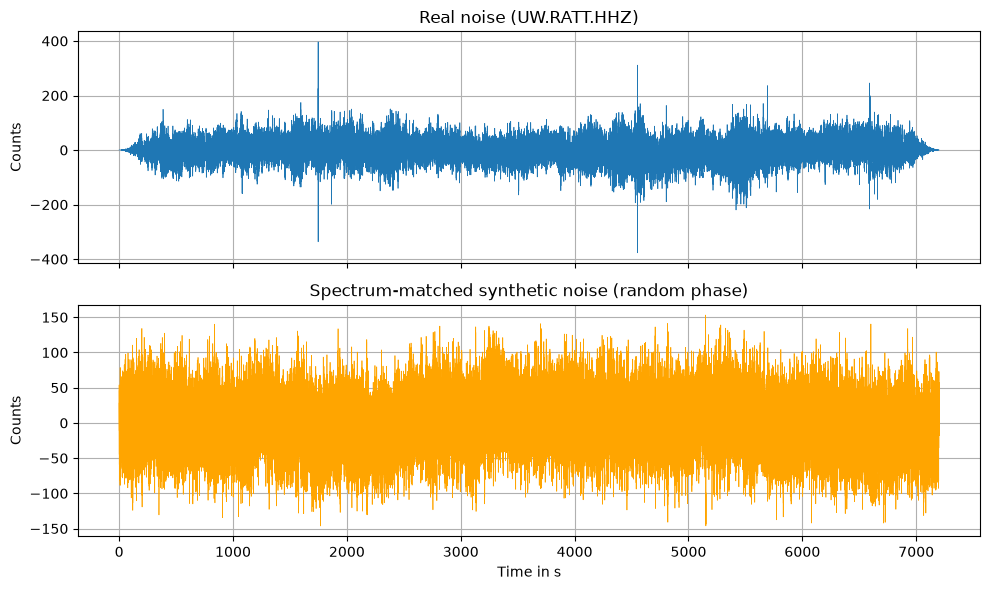

In [18]:
t_real = np.arange(len(real_noise)) / fs_real

fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
ax[0].plot(t_real, real_noise, lw=0.5)
ax[0].set_title('Real noise (UW.RATT.HHZ)')
ax[0].set_ylabel('Counts')
ax[0].grid()
ax[1].plot(t_real, synthetic_noise, lw=0.5, color='orange')
ax[1].set_title('Spectrum-matched synthetic noise (random phase)')
ax[1].set_xlabel('Time in s')
ax[1].set_ylabel('Counts')
ax[1].grid()
plt.tight_layout()
plt.show()

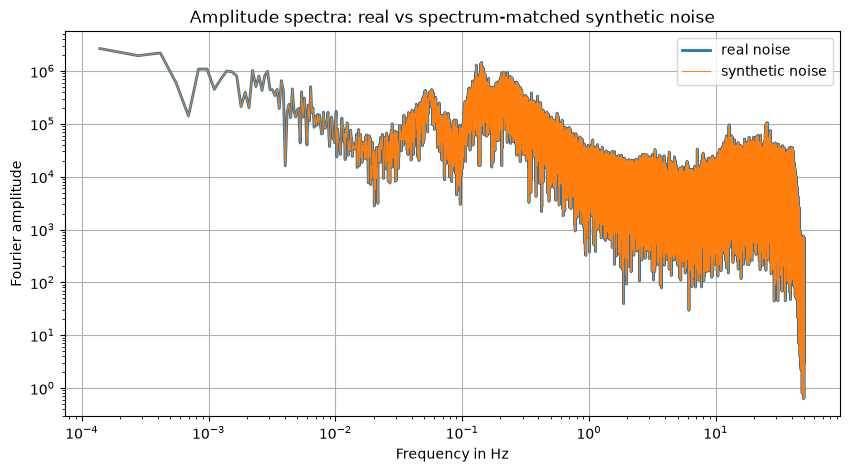

In [19]:
Nfft_real = next_fast_len(len(real_noise))
freq_real = np.fft.rfftfreq(Nfft_real, d=1 / fs_real)

spec_real = np.abs(np.fft.rfft(real_noise, n=Nfft_real))
spec_synth = np.abs(np.fft.rfft(synthetic_noise, n=Nfft_real))

plt.figure(figsize=(10, 5))
plt.loglog(freq_real[1:], spec_real[1:], lw=2, label='real noise')
plt.loglog(freq_real[1:], spec_synth[1:], lw=0.7, label='synthetic noise')
plt.xlabel('Frequency in Hz')
plt.ylabel('Fourier amplitude')
plt.title('Amplitude spectra: real vs spectrum-matched synthetic noise')
plt.legend()
plt.grid()
plt.show()

Los dos espectros caen uno encima del otro: la información de amplitud es idéntica. La información de fase no lo es. Podemos comprobarlo directamente.

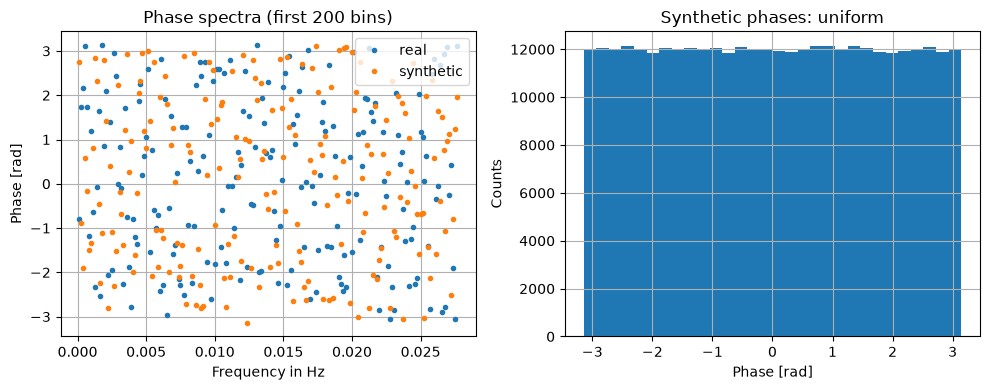

In [20]:
phase_real = np.angle(np.fft.rfft(real_noise, n=Nfft_real))
phase_synth = np.angle(np.fft.rfft(synthetic_noise, n=Nfft_real))

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].plot(freq_real[1:200], phase_real[1:200], '.', label='real')
ax[0].plot(freq_real[1:200], phase_synth[1:200], '.', label='synthetic')
ax[0].set_xlabel('Frequency in Hz')
ax[0].set_ylabel('Phase [rad]')
ax[0].set_title('Phase spectra (first 200 bins)')
ax[0].legend()
ax[0].grid()
ax[1].hist(phase_synth, bins=30)
ax[1].set_xlabel('Phase [rad]')
ax[1].set_ylabel('Counts')
ax[1].set_title('Synthetic phases: uniform')
ax[1].grid()
plt.tight_layout()
plt.show()

### 4.2 Aumentar un evento con ruido realista a SNR variable

Ahora combinamos las dos ideas: un evento sintético (la ondícula de Ricker) más ruido realista de espectro apareado, en un rango de niveles de SNR. Esta es una estrategia estándar de aumento de datos (*data augmentation*): una sola plantilla de evento limpia produce muchas muestras de entrenamiento con niveles de ruido controlados.

`spectrum_matched_noise` acepta una longitud de salida `n`, así que podemos sortear una realización de ruido de la misma longitud que la ventana de la señal.

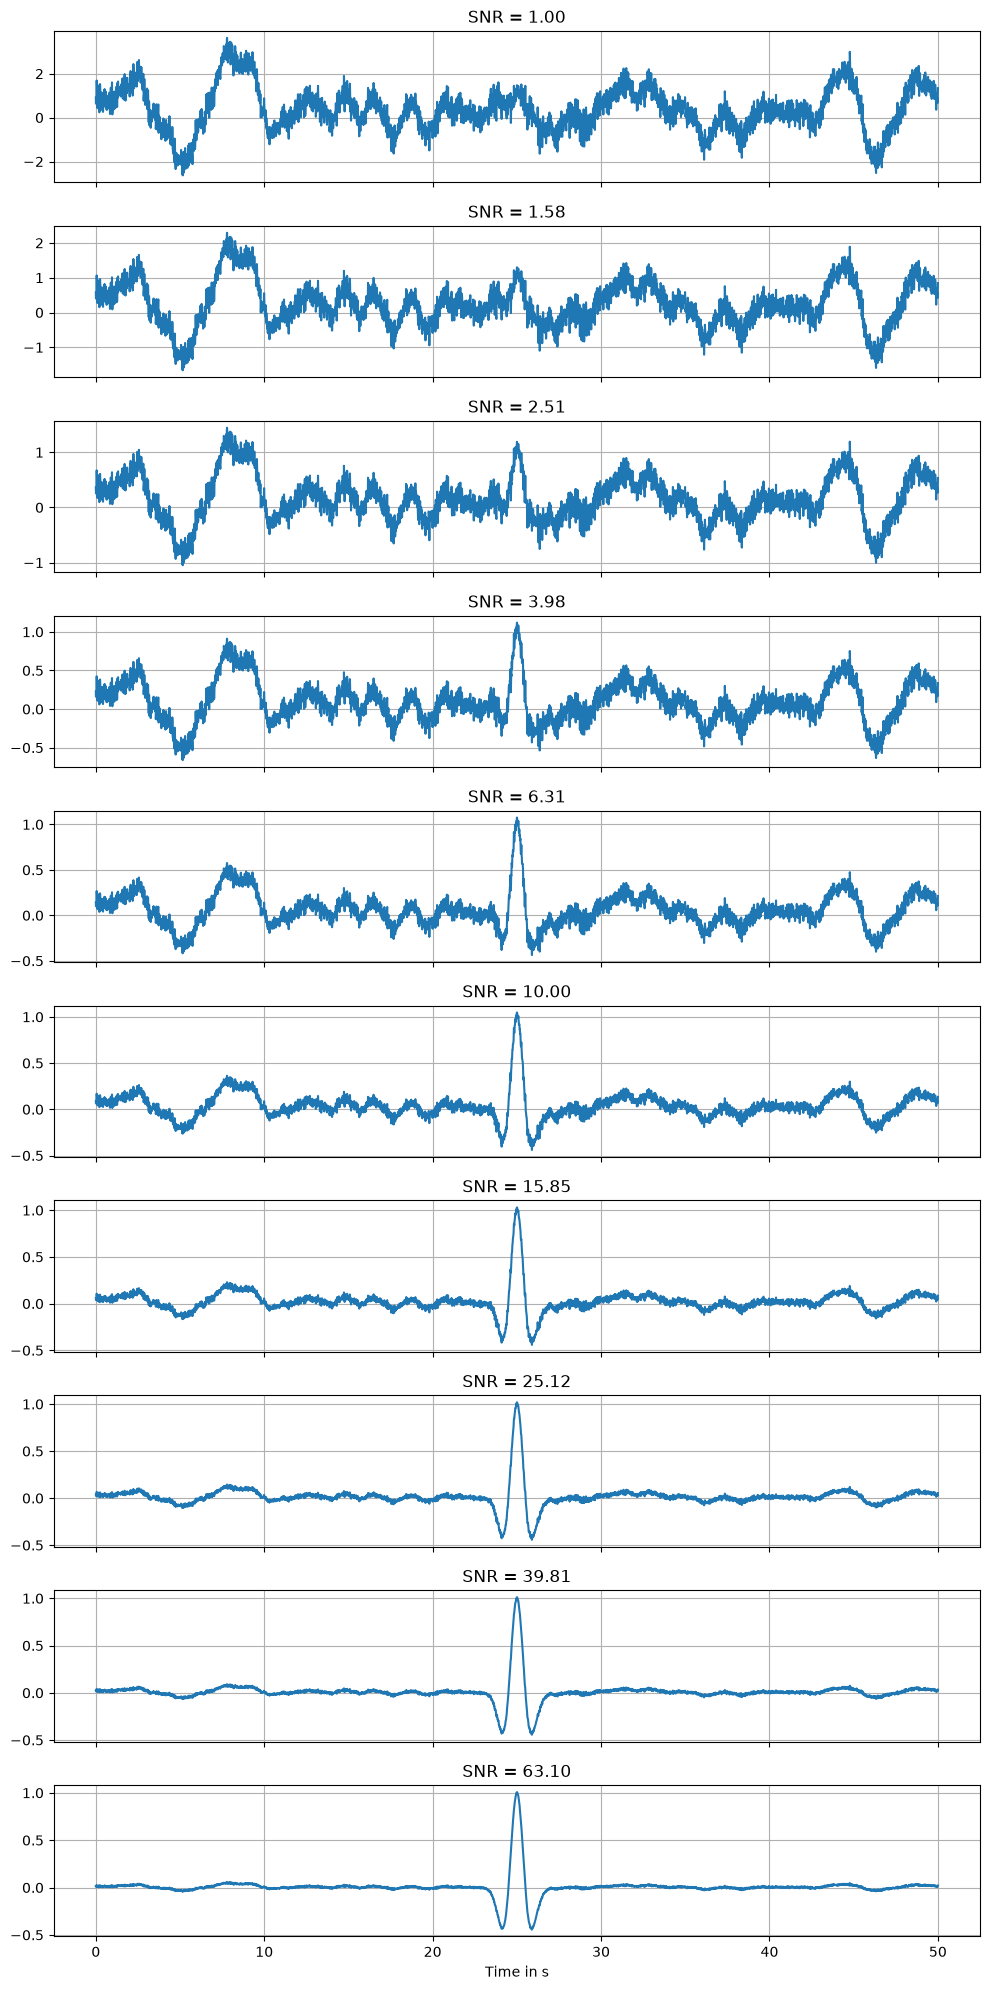

In [21]:
matched_noise = mlgeo_synth.spectrum_matched_noise(real_noise, n=len(s), seed=7)
matched_noise /= matched_noise.std()  # unit standard deviation, per our SNR definition

snr_levels = [np.power(10, i / 5) for i in range(10)]
fig, ax = plt.subplots(10, 1, figsize=(10, 20), sharex=True)
for i, snr in enumerate(snr_levels):
    ax[i].plot(t, s + matched_noise / snr)
    ax[i].set_title(f'SNR = {snr:.2f}')
    ax[i].grid()
ax[-1].set_xlabel('Time in s')
plt.tight_layout()
plt.show()

A SNR baja el evento desaparece dentro del ruido. En algún punto de esta escalera, cualquier detector — humano o algorítmico — empieza a fallar. Encontrar ese punto de falla es exactamente lo que hacemos a continuación, con el detector más antiguo de la caja de herramientas sismológica.

### 4.3 El generador de datos sintéticos del curso

El paquete `mlgeo_synth` usado arriba es el generador de datos sintéticos del curso. Además de `spectrum_matched_noise`, puede generar sismogramas sintéticos completos con una onda P, una onda S, una coda y ruido coloreado, además de conjuntos de datos etiquetados para ejercicios de clasificación. Nos apoyaremos en él en capítulos posteriores, cuando necesitemos datos con verdad de referencia conocida.

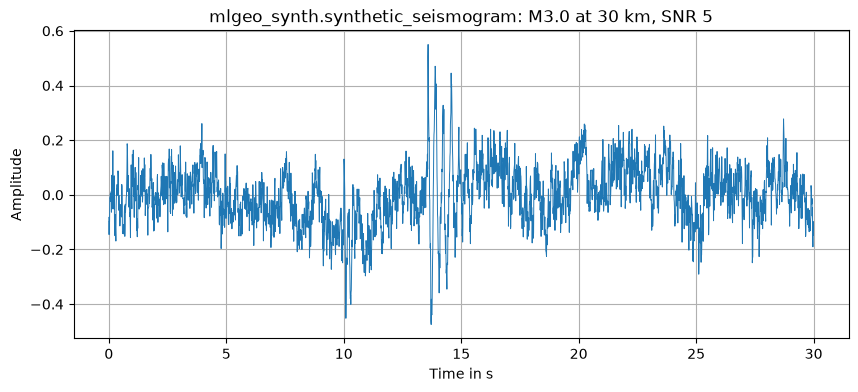

{'t_p': 10.0, 't_s': 13.571428571428571, 'peak_amplitude': np.float64(0.4841325757612952), 'snr': 5.0}


In [22]:
t_syn, trace, meta = mlgeo_synth.synthetic_seismogram(
    duration_s=30.0, fs=100.0, magnitude=3.0, distance_km=30.0, snr=5.0, seed=3)

plt.figure(figsize=(10, 4))
plt.plot(t_syn, trace, lw=0.7)
plt.xlabel('Time in s')
plt.ylabel('Amplitude')
plt.title('mlgeo_synth.synthetic_seismogram: M3.0 at 30 km, SNR 5')
plt.grid()
plt.show()
print(meta)

### 4.4 Ejemplo desarrollado: el piso de detección del STA/LTA

Antes de que cualquier red neuronal toque trazas como estas (el capítulo 4.3 entrena una), les debemos un modelo de referencia clásico. El detector **STA/LTA** (promedio de corto plazo sobre promedio de largo plazo; Allen, 1978) desliza dos ventanas sobre la traza: una ventana corta (aquí de 1 s) sigue el nivel instantáneo de la señal, una ventana larga (de 10 s) sigue el fondo, y su cociente se dispara cuando llega un transitorio. Ha corrido en las cadenas de disparo de los observatorios durante décadas, no tiene nada que entrenar, y cualquier detector aprendido debe superarlo para justificar su complejidad.

Un detector necesita un umbral, y el umbral debe salir del ruido solamente. Generamos 200 ventanas de puro ruido, registramos el pico de STA/LTA de cada una y fijamos el umbral en el percentil 99 de esa distribución: una tasa de falsas alarmas del 1 % por construcción, antes de mirar señal alguna. Luego corremos el detector sobre `s + noise / SNR` a lo largo de la escalera de SNR `np.logspace(-1, 2, 20)`, con 60 realizaciones frescas de ruido por SNR, y contamos la fracción de ensayos en los que el pico de STA/LTA cruza el umbral. Cada punto son 60 ensayos de Bernoulli, así que le adjuntamos un intervalo binomial (de Wilson).

In [23]:
from obspy.signal.trigger import classic_sta_lta

nsta, nlta = int(1 * fs), int(10 * fs)  # 1 s short window, 10 s long window


def peak_stalta(trace, nsta=nsta, nlta=nlta):
    """Peak STA/LTA of a trace, ignoring the first LTA window (not yet filled)."""
    cft = classic_sta_lta(trace, nsta, nlta)
    return cft[nlta:].max()


# Threshold choice: peak STA/LTA of 200 windows that contain no signal at all
n_noise_trials = 200
noise_peaks = np.array([
    peak_stalta(mlgeo_synth.spectrum_matched_noise(real_noise, n=len(s), seed=50_000 + k))
    for k in range(n_noise_trials)])
threshold = np.quantile(noise_peaks, 0.99)
print(f"noise-only peak STA/LTA: median {np.median(noise_peaks):.2f}, "
      f"99th percentile {threshold:.2f}")

noise-only peak STA/LTA: median 4.34, 99th percentile 6.09


SNR   0.10: detection probability 0.02
SNR   0.14: detection probability 0.02
SNR   0.21: detection probability 0.02
SNR   0.30: detection probability 0.02
SNR   0.43: detection probability 0.05
SNR   0.62: detection probability 0.00
SNR   0.89: detection probability 0.02
SNR   1.27: detection probability 0.03
SNR   1.83: detection probability 0.00
SNR   2.64: detection probability 0.07
SNR   3.79: detection probability 0.22
SNR   5.46: detection probability 0.62
SNR   7.85: detection probability 0.85
SNR  11.29: detection probability 0.98
SNR  16.24: detection probability 1.00
SNR  23.36: detection probability 1.00
SNR  33.60: detection probability 1.00
SNR  48.33: detection probability 1.00
SNR  69.52: detection probability 1.00
SNR 100.00: detection probability 1.00
detection probability crosses 50% near SNR 4.97


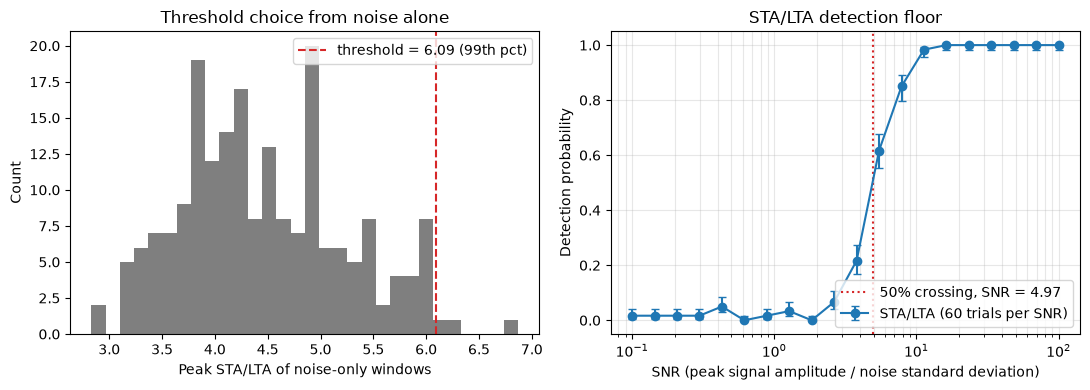

In [24]:
def wilson_interval(k, n, z=1.0):
    """Wilson score interval for a binomial proportion (z=1: roughly 68% coverage)."""
    p = k / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    half = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / denom
    return center - half, center + half


snrs_ex = np.logspace(-1, 2, 20)
n_trials = 60
detect_prob_stalta = np.zeros(len(snrs_ex))
err_lo, err_hi = np.zeros(len(snrs_ex)), np.zeros(len(snrs_ex))
for i, snr in enumerate(snrs_ex):
    hits = 0
    for k in range(n_trials):
        noise_k = mlgeo_synth.spectrum_matched_noise(real_noise, n=len(s), seed=1000 * i + k)
        noise_k /= noise_k.std()  # unit noise std; s has unit peak, so the SNR is exact
        hits += peak_stalta(s + noise_k / snr) >= threshold
    detect_prob_stalta[i] = hits / n_trials
    lo, hi = wilson_interval(hits, n_trials)
    err_lo[i], err_hi[i] = detect_prob_stalta[i] - lo, hi - detect_prob_stalta[i]

snr50 = np.interp(0.5, detect_prob_stalta, snrs_ex)
for snr, dp in zip(snrs_ex, detect_prob_stalta):
    print(f"SNR {snr:6.2f}: detection probability {dp:.2f}")
print(f"detection probability crosses 50% near SNR {snr50:.2f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(noise_peaks, bins=30, color='tab:gray')
ax[0].axvline(threshold, color='tab:red', ls='--',
              label=f'threshold = {threshold:.2f} (99th pct)')
ax[0].set_xlabel('Peak STA/LTA of noise-only windows')
ax[0].set_ylabel('Count')
ax[0].set_title('Threshold choice from noise alone')
ax[0].legend()
ax[1].errorbar(snrs_ex, detect_prob_stalta, yerr=[err_lo, err_hi], marker='o',
               capsize=3, label=f'STA/LTA ({n_trials} trials per SNR)')
ax[1].axvline(snr50, color='tab:red', ls=':', label=f'50% crossing, SNR = {snr50:.2f}')
ax[1].set_xscale('log')
ax[1].set_xlabel('SNR (peak signal amplitude / noise standard deviation)')
ax[1].set_ylabel('Detection probability')
ax[1].set_title('STA/LTA detection floor')
ax[1].grid(alpha=0.3, which='both')
ax[1].legend(loc='lower right')
fig.tight_layout()

El panel izquierdo es la lógica del umbral: el ruido puro produce una distribución de picos de STA/LTA (mediana cercana a 4.3 para este ruido rico en microsismos), y colocar el umbral en su percentil 99, 6.1, fija la tasa de falsas alarmas en 1 % antes de que cualquier señal entre al experimento. El panel derecho es el piso de detección: la curva se mantiene en el nivel de falsas alarmas de diseño, de 1-2 %, hasta una SNR de alrededor de 2.6, sube y cruza el 50 % cerca de SNR 5, y satura en 1 por encima de una SNR de alrededor de 16 — una transición de menos de una década de ancho. La moraleja: con su tasa de falsas alarmas clavada en 1 %, este detector clásico necesita una amplitud pico de aproximadamente cinco desviaciones estándar del ruido antes de dispararse con confiabilidad ante este evento. Ese número es el punto de referencia que cualquier detector aprendido tiene que superar; en el [capítulo 4.3](../Chapter4-DeepLearning/mlgeo_4.3_CNN.ipynb) superponemos esta curva sobre el piso de detección de una CNN entrenada, medido de la misma manera.

## 5. Ejercicios

### Ejercicio 1: ruido de espectro apareado a partir de otra ventana de referencia

```{admonition} 🤝 Asistente permitido
:class: tip
Use su asistente si quiere — verifique cada línea y declare el uso en su entrega ([1.8](../Chapter1-GettingStarted/1.8_ai_in_your_workflow.md)).
```

Descargue una ventana de ruido de dos horas distinta de UW.RATT (por ejemplo, 24 horas antes), genere ruido de espectro apareado a partir de ella y compárela con la ventana usada arriba:
1. Compare la varianza y la curtosis de las dos ventanas reales y de sus dos versiones sintéticas.
2. Superponga los cuatro espectros de amplitud. ¿Se mueven los picos microsísmicos de un día a otro?
3. Comente: ¿basta una sola ventana de ruido sintético para representar el ruido de esta estación?

In [25]:
# Exercise 1 scaffold
# Tstart2 = Tstart - 86400  # 24 hours earlier
# N2 = fdsn_client.get_waveforms(network=network, station=station, location='--',
#                                channel=channel, starttime=Tstart2 - 7200,
#                                endtime=Tstart2, attach_response=True)
# N2.merge(); N2.detrend(type='linear'); N2[0].taper(max_percentage=0.05)
# real_noise2 = N2[0].data.astype(float) - N2[0].data.mean()
# synthetic_noise2 = mlgeo_synth.spectrum_matched_noise(real_noise2, seed=42)
# from scipy.stats import kurtosis
# ... compare np.var and kurtosis of the four series, then overlay their spectra

```{admonition} Autoverificación
:class: dropdown
- Ambas ventanas reales tienen 720,000 muestras (dos horas a 100 Hz), igual que sus versiones sintéticas.
- Cada ventana sintética reproduce de cerca la varianza de su propia ventana de referencia; los dos días pueden diferir entre sí por un factor apreciable.
- `scipy.stats.kurtosis` devuelve el exceso de curtosis, así que las ventanas sintéticas (de fase aleatoria y, por lo tanto, gaussianas) quedan cerca de 0; las ventanas reales pueden desviarse si hay transitorios presentes.
- En los espectros superpuestos, cada curva sintética cae encima de su propia curva real. Entre días, los picos microsísmicos (aproximadamente 0.1-1 Hz) se mantienen cerca de las mismas frecuencias pero cambian de amplitud.
- Parte 3: los cambios de nivel y de forma espectral de un día a otro implican que una sola ventana subrepresenta el ruido de la estación; sortear de varias ventanas es más seguro.
```

### Ejercicio 2: mueva el piso de detección del STA/LTA

```{admonition} 🤝 Asistente permitido
:class: tip
Use su asistente si quiere — verifique cada línea y declare el uso en su entrega ([1.8](../Chapter1-GettingStarted/1.8_ai_in_your_workflow.md)).
```

El piso de detección de la sección 4.4 se midió con un par de ventanas específico: 1 s la corta, 10 s la larga. Esas longitudes son las únicas perillas de ajuste del detector, y los observatorios las eligen según las señales que persiguen.

1. Repita el barrido de la sección 4.4 para tres pares de ventanas: (0.5 s, 5 s), (1 s, 10 s) y (2 s, 20 s). Para cada par, recalcule primero el umbral a partir de ventanas de puro ruido — la distribución del ruido cambia con las ventanas — y luego mida la curva de detección y su cruce del 50 %.
2. Grafique las tres curvas de detección sobre un mismo eje. ¿Qué par de ventanas detecta el evento de Ricker a la SNR más baja, y cómo se relaciona eso con la duración del evento, de aproximadamente 1 s?
3. ¿Qué sale mal si conserva el umbral de 1 s / 10 s mientras cambia las ventanas?

In [26]:
# Exercise 2 scaffold
# for sta_s, lta_s in [(0.5, 5.0), (1.0, 10.0), (2.0, 20.0)]:
#     n_s, n_l = int(sta_s * fs), int(lta_s * fs)
#     # 1) recompute the threshold: peak_stalta of 200 noise-only windows with
#     #    these window lengths, take the 99th percentile
#     # 2) rerun the SNR sweep of Section 4.4 with peak_stalta(..., n_s, n_l)
#     # 3) record the 50% crossing with np.interp(0.5, detect_prob, snrs_ex)
# plot the three curves on one semilogx axis and compare the crossings

```{admonition} Autoverificación
:class: dropdown
- Cada par de ventanas necesita su propio umbral: la distribución de picos con puro ruido se desplaza cuando cambian las ventanas (una ventana corta más larga promedia más muestras de ruido, así que sus picos son más bajos). Espere tres percentiles 99 distintos.
- Las tres curvas de detección suben desde el piso de falsas alarmas del 1% hasta 1, y cada cruce del 50% queda dentro de aproximadamente un factor de dos del valor de la sección 4.4 (SNR cercana a 5).
- La ventana corta más próxima a la duración del evento (alrededor de 1 s para esta ondícula de Ricker) da el cruce más bajo: una STA de 0.5-2 s integra la mayor parte de la energía del evento, mientras que una STA mucho más larga la diluye con el ruido circundante.
- Reutilizar el umbral de 1 s / 10 s con otras ventanas rompe la calibración de falsas alarmas del 1%: la comparación entre curvas deja de ser justa, porque cada detector opera a una tasa de falsas alarmas distinta. La probabilidad de detección solo significa algo a una tasa de falsas alarmas declarada.
```

## 6. ¿Cuándo son admisibles los datos sintéticos?

Los datos sintéticos son una herramienta, no un sustituto de la observación. Use esta lista de verificación antes de incorporar datos sintéticos a un proyecto.

**Admisible:**
- **Desarrollo de métodos.** Prototipar un detector, un filtro o un modelo sobre datos con verdad de referencia conocida antes de tocar datos reales.
- **Evaluación comparativa (*benchmarking*).** Medir la exactitud (*accuracy*), la exhaustividad (*recall*) o los puntos de falla (como en el ejercicio 2) exige conocer la respuesta verdadera. Los datos sintéticos la proporcionan.
- **Aumento de datos con procedencia declarada.** Agregar realizaciones de ruido o eventos sintéticos a un conjunto de entrenamiento es práctica estándar, siempre que el artículo o el informe declare qué muestras son sintéticas y cómo se generaron.
- **Conjuntos de prueba ocultos.** Los instructores y quienes mantienen los *benchmarks* usan datos sintéticos para construir conjuntos de prueba que los modelos no pueden haber memorizado.

**No admisible:**
- **Sustituir la validación real en afirmaciones científicas.** Un modelo validado solo con datos sintéticos no ha sido validado. Una conclusión científica sobre la Tierra debe descansar en observaciones reales.

**Declare siempre.** Cada vez que los datos sintéticos entren en un análisis, dígalo: qué muestras, qué generador, qué semilla. El código del generador y las semillas pertenecen al repositorio junto con el resto del proyecto. En este curso, use el paquete `mlgeo_synth` como generador para que la procedencia quede a un import de distancia, y siga la guía de proyecto en [las instrucciones del proyecto MLGeo](../about_this_book/0_mlgeo_project.md).